In [2]:
import oopModules
# dummy comment
import sympy
import importlib
importlib.reload(oopModules)

<module 'oopModules' from '/home/verley/Gatien_pro/Projets/ConductanceMatrix/coupling-schlogl/oopModules.py'>

We first play with a limit case of a single conservation law where Will and Jed's code has not been tested and care has to be taken when measuring the conduictances.

In [11]:
#  stoichiometric matrix for the Schlogl model, 2 chemostatted species and 1 free species

stoichio = sympy.Matrix([
    [1,1],
    [-1,0],
    [0,-1],
    # [0,0,-1]
])

names = ["X","Y1","Y2"]

#, "Y3"]

n_internal = 1

schlogl1 = oopModules.ModuleProperties(stoichio, n_internal, names)

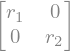

In [12]:
schlogl1.calculate_reaction_resistance_matrix()

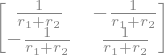

In [13]:
schlogl1.calculate_physical_conductance_matrix()

In [14]:
schlogl1.calculate_fundamental_resistance_matrix()

We should find serial combination of the resistances in this simple case.


## Analytical solution of the coductance/resistance

We adapt 

$$
\begin{gathered}
Y_1 \underset{k_1^{-}}{\stackrel{k_1^{+}}{\rightleftharpoons}} X_0 \\
Y_2+2 X_0 \stackrel{k_2^{+}}{\underset{k_2^{-}}{\rightleftharpoons}} 3 X_0
\end{gathered}
$$

https://pubs.aip.org/aip/jcp/article/160/13/134103/3280175/Nonequilibrium-fluctuations-of-chemical-reaction 


$x$ is the conncentration of X (the free species) at steady state given the boundaires $c_a,c_b$

In [15]:
k1p, k1m, k2p, k2m, y1, y2, x = sympy.symbols("k1^+, k1^-, k2^+, k2^-, y_1, y_2, x")

eq = -k2m*x**3+y2*k2p*x**2-k1m*x+y1*k1p
eq

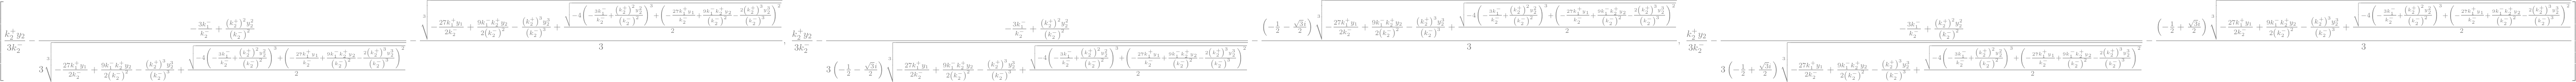

In [16]:
xss = sympy.solve(eq, x) # pick the first one because it is ~real!

xss


In [32]:
lambda_x0 = sympy.lambdify((k1m, k1p, k2p, k2m, y1, y2), xss[0], 'scipy')
lambda_x1 = sympy.lambdify((k1m, k1p, k2p, k2m, y1, y2), xss[1], 'scipy')
lambda_x2 = sympy.lambdify((k1m, k1p, k2p, k2m, y1, y2), xss[2], 'scipy')

### TODO # THIS IS PROBALY NOT GOOD, REPLACE WITH NUMPY ROOTS, we will define an implicit function...
## 

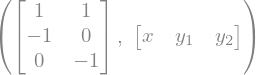

In [18]:

stoichio_in = sympy.Matrix([
    [0,2],
    [1,0],
    [0,1]
])      


stoichio_out = sympy.Matrix([
    [1,3],
    [0,0],
    [0,0]
])

stoichio_full = stoichio_out - stoichio_in


Z = sympy.Matrix([[x,y1,y2]])
stoichio_full,Z

In [19]:
# # sympy.exp(stoichio_in[:,0]@sympy.log(Z))

# def 
# logZ = Z.applyfunc(sympy.log)

# (logZ*stoichio_in[:,0]).applyfunc(sympy.exp)


#### Currents
Calculate the currents on the two reactions

$$
\begin{aligned}
& y_1 k_1^{+}-x k_1^{-}=j_1 \\
& y_2 x^2 k_2^{+}-k_2^{-} x^3=j_2
\end{aligned}
$$

In [20]:
j1 = y1*k1p-x*k1m
j2 = y2*k2p*x**2-x**3*k2m

j1,j2

In [21]:
j1+j2

In [22]:
eq == j1+j2

True

We need also the edge forces to finally calculate the resistances

#### Edge forces

$$
\begin{aligned}
& f_1=\ln \frac{y_1 k_1^{+}}{x k_1^{-}} \\
& f_2=\ln \frac{y_2 x^2 k_2^{+}}{x^3 k_2^{-}}
\end{aligned}
$$

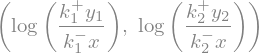

In [23]:
f1 = sympy.log(y1*k1p/(x*k1m))
f2 = sympy.log(y2*x**2*k2p/x**3/k2m)

f1,f2

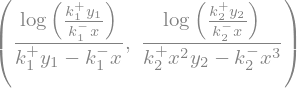

In [24]:
r1 = f1/j1
r2 = f2/j2

r1, r2



In [25]:
lambda_r1 = sympy.lambdify((k1m, k1p, k2p, k2m, y1, y2,x), r1, 'numpy')
lambda_r2 = sympy.lambdify((k1m, k1p, k2p, k2m, y1, y2,x), r2, 'numpy')

According to the previous code, we just sum the two in series.

In [169]:



def schlogl_conductance( rates, left_reservoir, right_reservoir,verbose=False):
    """ 
    
    """
    k1p, k1m, k2p, k2m, = rates
    _x0 = lambda_x0(k1m, k1p, k2p, k2m, left_reservoir, right_reservoir)
    _x1 = lambda_x1(k1m, k1p, k2p, k2m, left_reservoir, right_reservoir)
    _x2 = lambda_x2(k1m, k1p, k2p, k2m, left_reservoir, right_reservoir)
    
    _x = _x0
    if verbose:
        print (f"sols: {_x0}, {_x1}, {_x2}")
    # if np.isnan(_x):
    #     return 
    # print("x =", _x)
    _r1 = lambda_r1(k1m, k1p, k2p, k2m, left_reservoir, right_reservoir,_x)
    _r2 = lambda_r2(k1m, k1p, k2p, k2m, left_reservoir, right_reservoir,_x)

    return   1.0/(_r1+_r2),

def internal_concentration(rates, left_reservoir, right_reservoir):
    k1p, k1m, k2p, k2m, = rates
    _x0 = lambda_x0(k1m, k1p, k2p, k2m, left_reservoir, right_reservoir)
  
    return _x0





In [30]:
schlogl_conductance(1,1,1,1,0.1,2.0)

sols: nan, (nan+nanj), (nan+nanj)


In [17]:
# À lu Udo we fix all the ks to 1
#  we need y2 <sqrt(3) and y1 can be anyhting reasonable around 1.0 
import numpy as np
import matplotlib.pyplot as plt

Y1 = 5
Y2 = np.linspace(1., 2.0, 20)
G = np.zeros_like(Y2)
for i, _y in enumerate(Y2):
    print("y2 =", _y)
    G[i] = schlogl_conductance(1,1,1,1, Y1, _y)
    # print(_y, G[i])

y2 = 1.0
sols: 1.881239401076466, (-0.44061970053823313+1.569610321890014j), (-0.44061970053823313-1.569610321890014j)
y2 = 1.0526315789473684
sols: 1.9052200792539127, (-0.4262942501532724+1.5628953715496339j), (-0.4262942501532724-1.5628953715496339j)
y2 = 1.1052631578947367
sols: 1.9297391904909045, (-0.41223801629808376+1.5559831392530903j), (-0.41223801629808376-1.5559831392530903j)
y2 = 1.1578947368421053
sols: 1.9548039448455925, (-0.3984546040017437+1.5488819167511794j), (-0.3984546040017437-1.5488819167511794j)
y2 = 1.2105263157894737
sols: 1.9804210258347295, (-0.38494735502262806+1.541600209299947j), (-0.38494735502262806-1.541600209299947j)
y2 = 1.263157894736842
sols: 2.0065965447018472, (-0.3717193249825026+1.534146723638954j), (-0.3717193249825026-1.534146723638954j)
y2 = 1.3157894736842106
sols: 2.033335996180641, (-0.3587732612482153+1.5265303534943397j), (-0.3587732612482153-1.5265303534943397j)
y2 = 1.368421052631579
sols: 2.0606442163393037, (-0.3461115818538625+1.5

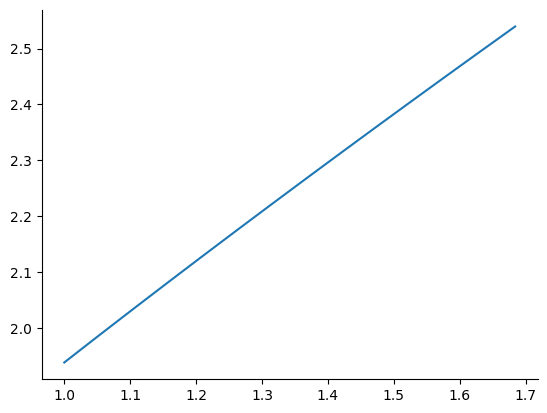

In [18]:
plt.plot(Y2, G, '-')

In [19]:
Y2

array([1.        , 1.05263158, 1.10526316, 1.15789474, 1.21052632,
       1.26315789, 1.31578947, 1.36842105, 1.42105263, 1.47368421,
       1.52631579, 1.57894737, 1.63157895, 1.68421053, 1.73684211,
       1.78947368, 1.84210526, 1.89473684, 1.94736842, 2.        ])

In [21]:
# replacements = {k1m:1, k1p:1, k2p:1, k2m:1, y1:1.0}

# px = xss.subs(replacements)
# sympy.simplify(px)

In [22]:
# peq = sympy.simplify(eq.subs(replacements))

# peq

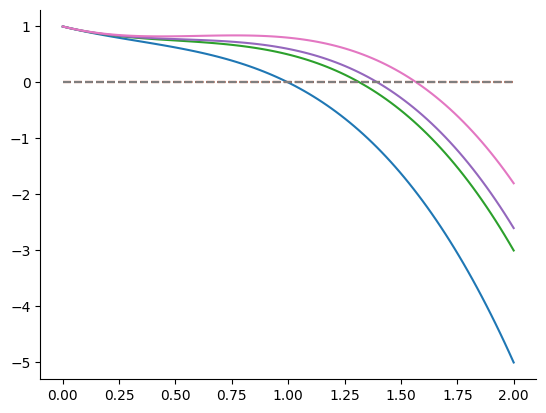

In [23]:
x = np.linspace(0, 2.0, 100)
Y2 = [1.,1.5, 1.6,1.8]
for _y in Y2:
    plt.plot(x,-x**3+x**2*_y-x+1.0, '-')
    plt.plot(x, np.zeros_like(x), '--')

In [24]:
lambda_x0(1,1,1,1,1.0,1.8)

Many problems, to check properly tha the solution makes sense also close to criticality at sqrt(3)....

## Combine two modules and find internal species

We try the minimising algorithm on the chain of two Schlogl modules.


This means:

- having two analytical expressions for the two conductance matrices
- fixing the external bouyndary conditions
- vary in some ways the internal species until the current of Y2 of module 1 is the current of Y1 in module 2


## Calculate currents from conductances

$$J = GA$$

For the special choice of all the rates equal to 1.0, we are the, we ignore the standard chemical potentials $\mu_i^\circ$ (Gatien's notation), so thephysical forces are

$$a_i = \mu_i^\circ + RT \log Y_i = \log Y_i$$

where we take $RT=1$


$$A^T = a^TS$$
where S is the selection matrix


For a single module

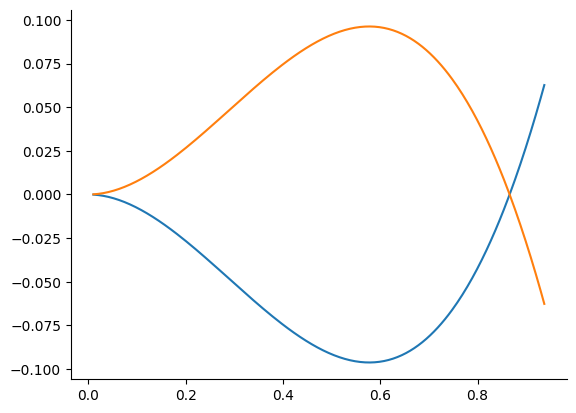

In [92]:
S = schlogl1.selection_matrix

Y1 = np.linspace(0.01,1.0,200)

Y2 = np.sqrt(3)/2 

x = sympy.symbols("x")
# for _y in Y1:
lambda_j1 = sympy.lambdify((k1m, k1p,y1, x), j1, 'numpy')
lambda_j2 = sympy.lambdify((k2m,k2p,y2, x), j2, 'numpy')

xs =np.array([np.roots([-1,Y2,-1,_y])[-1].real for _y in Y1])
_xs = np.array([lambda_x0(1,1,1,1,_y,Y2) for _y in Y1])

_j1 = np.array([lambda_j1(1,1,_y,  xs[i]) for i,_y in enumerate(Y1)])
_j2 = np.array([lambda_j2(1,1,Y2, xs[i]) for i,_y in enumerate(Y1)])

# _j1 = Y1-xs
plt.plot(xs,_j1, '-')
plt.plot(xs,_j2, '-')


In [55]:
eq

sols: 0.010087091217643729, (0.4279691562833974+0.8990041565168314j), (0.4279691562833974-0.8990041565168314j)
sols: 0.015170698665629034, (0.4254273525594048+0.8978326722472878j), (0.4254273525594048-0.8978326722472878j)
sols: 0.020298202757666473, (0.42286360051338606+0.8966714187241278j), (0.42286360051338606-0.8966714187241278j)
sols: 0.025469904966128387, (0.42027774940915513+0.8955209348071749j), (0.42027774940915513-0.8955209348071749j)
sols: 0.030686082794719793, (0.4176696604948594+0.8943817770597371j), (0.4176696604948594-0.8943817770597371j)
sols: 0.03594698749286801, (0.41503920814578527+0.8932545198616051j), (0.41503920814578527-0.8932545198616051j)
sols: 0.041252841657557604, (0.41238628106344044+0.8921397554653344j), (0.41238628106344044-0.8921397554653344j)
sols: 0.04660383672421664, (0.4097107835301109+0.8910380939890091j), (0.4097107835301109-0.8910380939890091j)
sols: 0.052000130349463214, (0.40701263671748766+0.8899501633383198j), (0.40701263671748766-0.889950163338

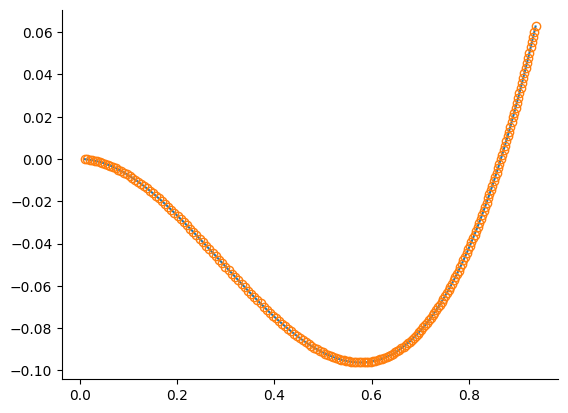

In [ ]:
# check that the condictance also work
#  G (logY1-logY2)
j = np.array([schlogl_conductance(1,1,1,1,_y, Y2) for _y in Y1])*(-np.log(Y1)+np.log(Y2))

plt.plot(xs,j, '-')
plt.plot(xs,_j1, 'o', mfc="None")

In [170]:
import numpy as np


class InterfacialPotentialCalculator:
    def __init__(self, 
                 conductance_matrix_func,  # this must produce a n_fundamental_forces x n_fundamental_forces matrix, given the rates and the left and right reservoir concentrations, which is 1 by 1 for teh standard Schlogl model
                 interface_concentration, 
                 dirichlet_concentration , 
                 selection_matrix,  # this is a n_reservoirs x n_fundamental_forces matrix, which is 2 by 1 for the standard Schlogl model
                 rates = [1,1,1,1], #Udo's setting
                 interface_location="right",
                 standard_chemical_potential = 0, 
                 RT=1.0):
        
        if selection_matrix is None:
            raise ValueError("Selection matrix must be provided.")
        
        S = np.array(selection_matrix).astype(np.float32)  # must be n_reservoirs x n_fundamental_forces

        self.selection_matrix = S
        self.standard_chemical_potential = standard_chemical_potential
        self.RT = RT
        self.conductance_matrix_func = conductance_matrix_func
        self.interface_concentration = interface_concentration
        
        self.dirichlet_concentration = dirichlet_concentration
        self.interface_location = interface_location
        self.rates = rates


        if self.interface_location not in ["left", "right"]:
            raise ValueError("interface_location must be either 'left' or 'right'.")



        self.update()  # Initialize the calculations
  
    
    def fundamental_force_from_concentrations(self):
        # local potentials 
        a = np.array([self.left_reservoir, self.right_reservoir])
        mu = self.standard_chemical_potential + self.RT * np.log(a)  # mu should be the energy per mole 
        A = self.selection_matrix.T @ mu
        
        self.fundamental_forces_A = A
     

    def fundamental_current_from_conductance(self):

        I = self.conductance_matrix * self.fundamental_forces_A
        self.fundamental_current_I = I

    def physical_current_from_fundamental_current(self):
        """ We compute the physical currents (called "i" in the papers) from the fundamental currents using the selection matrix. """
        i = self.selection_matrix @ self.fundamental_current_I
        self.physical_current_i = i

    def project_physical_to_interface(self):
        """ 
        We want now to extract only the interface currents, so we need to know 'where' the interface is.
        """
        self.interface_currents = self.physical_current_i[self.interface_mask]

    
    def update(self,interface_concentration=None):  

        if interface_concentration is not None:
            self.interface_concentration = interface_concentration

        if self.interface_location == "left":
            self.left_reservoir = self.interface_concentration
            self.right_reservoir = self.dirichlet_concentration

            # for the case where we have vectors for the interfacial and dirichlet concentrations, we need to know which of the n_rservoirs are interface or dirichlet
            # 
            self.interface_mask = np.array([1,0], dtype=bool) #HARD CODED FOR SCHLOGL TODO: GENERALISE!
        else:
            self.left_reservoir = self.dirichlet_concentration
            self.right_reservoir = self.interface_concentration
            self.interface_mask = np.array([0,1], dtype=bool) #HARD CODED FOR SCHLOGL TODO: GENERALISE!
            
        self.conductance_matrix = self.conductance_matrix_func(self.rates, self.left_reservoir, self.right_reservoir)

        self.internal_concentration = internal_concentration(self.rates, self.left_reservoir, self.right_reservoir) ##ad Hoc pour Schlogl
        # print("Conductance matrix:", self.conductance_matrix)
        self.fundamental_force_from_concentrations()
        self.fundamental_current_from_conductance()
        self.physical_current_from_fundamental_current()
        self.project_physical_to_interface()



# calc = InterfacialPotentialCalculator(
#     conductance_matrix_func=schlogl_conductance,
#     interface_concentration=1.0,
#     dirichlet_concentration=1.2,
#     selection_matrix=schlogl1.selection_matrix,
#     interface_location="right",
#     # rates=[1,1,1,1]
# )


# print(calc.fundamental_forces_A ,-np.log(Y1)+np.log(Y2))

# print(calc.fundamental_current_from_conductance())
# print(calc.physical_current_from_fundamental_current())
# print(calc.interface_currents)

# calc.interface_currents

guess: 0.6
module1.interface_currents: [-0.16444894]
module1.interface_currents: [-0.19623912]


Text(0, 0.5, 'Internal Concentration')

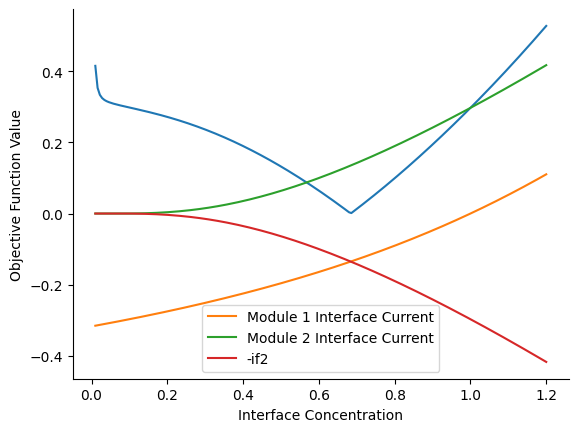

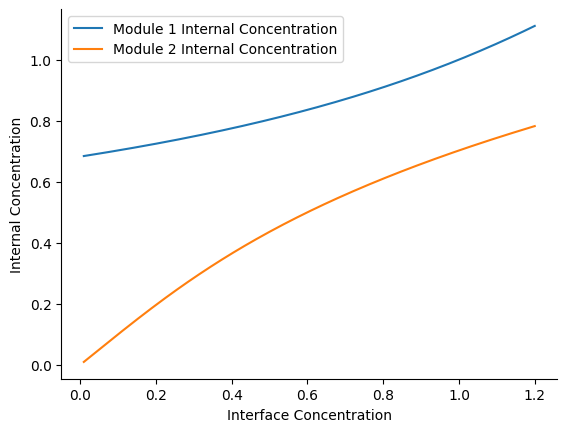

In [175]:
## construct two modules 
rng = np.random.default_rng(42)

# guess = rng.uniform(0.1, 1.2)
guess  = 0.6

print("guess:", guess)
module1 = InterfacialPotentialCalculator(
    conductance_matrix_func=schlogl_conductance,
    interface_concentration=guess,
    dirichlet_concentration=1.0,
    selection_matrix=schlogl1.selection_matrix,
    interface_location="right",
    rates=[1,1,1,1]
)

module2 = InterfacialPotentialCalculator(
    conductance_matrix_func=schlogl_conductance,
    interface_concentration=guess,
    dirichlet_concentration=0.1,
    selection_matrix=schlogl1.selection_matrix,
    interface_location="left",
    rates=[1,1,1,1]
)

print("module1.interface_currents:", module1.interface_currents)
# print("module2.interface_currents:", module2.interface_currents)

module1.update(interface_concentration=0.5)

print("module1.interface_currents:", module1.interface_currents)

def objective_function(x,regularisation):
    module1.update(interface_concentration=x)
    module2.update(interface_concentration=x)
    # print(f"{x} {module1.interface_currents[0]} {module2.interface_currents[0]}")
    # penalise very small currents to avoid trivial solutions

    ic1 = module1.interface_currents
    ic2 = module2.interface_currents

    return np.linalg.norm(ic1 + ic2)+regularisation/x**2

guesses = np.linspace(0.01, 1.2, 200)
objectives = [objective_function(x, 0.00001) for x in guesses]

if1 = []
if2 = []
internal1 = []
internal2 = []
for g in guesses:
    module1.update(interface_concentration=g)
    module2.update(interface_concentration=g)
    if1.append(module1.interface_currents[0])
    if2.append(module2.interface_currents[0])
    internal1.append(module1.internal_concentration)
    internal2.append(module2.internal_concentration)

if1 = np.array(if1)
if2 = np.array(if2)
import matplotlib.pyplot as plt
plt.plot(guesses, objectives)
plt.plot(guesses, if1, label="Module 1 Interface Current")
plt.plot(guesses, if2, label="Module 2 Interface Current")
plt.plot(guesses, -if2, label="-if2")
plt.xlabel("Interface Concentration")
plt.ylabel("Objective Function Value")
plt.legend()
plt.figure()
plt.plot(guesses, internal1, label="Module 1 Internal Concentration")
plt.plot(guesses, internal2, label="Module 2 Internal Concentration")   
plt.legend()
plt.xlabel("Interface Concentration")
plt.ylabel("Internal Concentration")    

In [160]:
from scipy.optimize import minimize_scalar


def objective_function(x,regularisation, module1=module1, module2=module2):
    module1.update(interface_concentration=x)
    module2.update(interface_concentration=x)
    # print(f"{x} {module1.interface_currents[0]} {module2.interface_currents[0]}")
    # penalise very small currents to avoid trivial solutions

    ic1 = module1.interface_currents
    ic2 = module2.interface_currents

    return np.linalg.norm(ic1 + ic2)+regularisation/x**2

m1 = InterfacialPotentialCalculator(
    conductance_matrix_func=schlogl_conductance,
    interface_concentration=0.5,
    dirichlet_concentration=1.0,
    selection_matrix=schlogl1.selection_matrix,
    interface_location="right",
    rates=[1,1,1,1]
)



m2 = InterfacialPotentialCalculator(
    conductance_matrix_func=schlogl_conductance,
    interface_concentration=0.5,
    dirichlet_concentration=0.2,
    selection_matrix=schlogl1.selection_matrix,
    interface_location="left",
    rates=[1,1,1,1]
)

result = minimize_scalar(objective_function, args=(0.00001,m1, m2), bounds=(0.01, 1.2), method='bounded')
optimal_concentration = result.x
print("Optimal Interface Concentration:", optimal_concentration)


Optimal Interface Concentration: 0.7061275693796385


## Characterise a single module to understand the combination

In [ ]:
for g in guesses:
    m1.update(interface_concentration=g)

m1 = InterfacialPotentialCalculator(
    conductance_matrix_func=schlogl_conductance,
    interface_concentration=0.5,
    dirichlet_concentration=1.0,
    selection_matrix=schlogl1.selection_matrix,
    interface_location="right",
    rates=[1,1,1,1]
)
